<div style="text-align:center; margin-top:40px;">

<img src="img/python_logo.png" width="550">

<h1 style="
font-family:'Times New Roman', serif;
font-size:42px;
font-weight:bold;
margin-top:30px;
margin-bottom:10px;
">

3_2_5_Descriptores_textura

</h1>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
">

14 de julio de 2026

</p>

<h2 style="
font-family:'Times New Roman', serif;
font-size:28px;
font-weight:bold;
margin-top:35px;
">

Procesamiento Digital de Imágenes<br>
Descriptores de Textura

</h2>

<p style="
font-family:'Times New Roman', serif;
font-size:22px;
margin-top:30px;
margin-bottom:5px;
">

Kevin Xavier Suasnavas Villarreal

</p>

<p style="
font-family:'Times New Roman', serif;
font-size:18px;
margin-top:5px;
">

<a href="https://github.com/kevinsuas433/Machine2026.git">

<strong>🔗 Link a mi GitHub:</strong>

https://github.com/kevinsuas433/Machine2026.git
</a>

</p>

<a href="https://github.com/kevinsuas433/Machine2026.git">

</a>

</div>

---

# 1. Descriptores de Textura

En esta práctica se estudiarán diferentes **descriptores de textura**, los cuales permiten caracterizar una imagen a partir de la distribución espacial de la intensidad de sus píxeles.

Se analizarán distintos métodos utilizados en visión por computador como la **Matriz de Coocurrencia (GLCM)**, **SIFT**, **Histogram of Oriented Gradients (HOG)** y **Local Binary Patterns (LBP)**, herramientas ampliamente utilizadas en tareas de clasificación, reconocimiento y análisis de imágenes.

---

## Selección de regiones de interés

Antes de calcular los descriptores de textura, es necesario seleccionar pequeñas regiones de la imagen que representen diferentes superficies.

En este ejercicio se marcarán dos zonas de estudio:

- **Cielo**, representado por una textura relativamente uniforme.
- **Hierba**, caracterizada por una textura con mayor variación.

Estas regiones servirán posteriormente para comparar sus características mediante diferentes descriptores de textura.

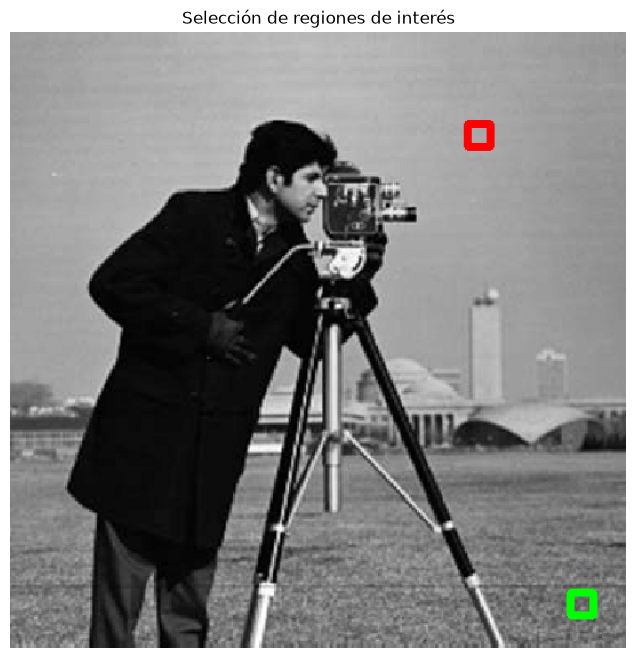

In [2]:
# ==========================================================
# Importación de librerías
# ==========================================================

# Matplotlib se utilizará para visualizar las imágenes.
import matplotlib.pyplot as plt

# OpenCV permitirá cargar y procesar la imagen.
import cv2

# NumPy facilita el manejo de matrices.
import numpy as np


# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen que será utilizada durante la práctica.
img = cv2.imread("images/photographer.png")


# ==========================================================
# Selección de regiones de interés (ROI)
# ==========================================================

# Dibujamos un rectángulo rojo sobre la región del cielo.
window = cv2.rectangle(
    img.copy(),
    (400, 80),
    (420, 100),
    (0, 0, 255),
    5
)

# Dibujamos un rectángulo verde sobre la región de la hierba.
window = cv2.rectangle(
    window,
    (490, 490),
    (510, 510),
    (0, 255, 0),
    5
)


# ==========================================================
# Visualización del resultado
# ==========================================================

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(window, cv2.COLOR_BGR2RGB))
plt.title("Selección de regiones de interés")
plt.axis("off")
plt.show()

## Extracción de las regiones seleccionadas

Una vez identificadas las zonas de interés, se extraen ambas regiones de la imagen original para analizarlas de forma independiente.

Estas pequeñas muestras permitirán comparar cómo se comportan los diferentes descriptores de textura en superficies con características visuales distintas.

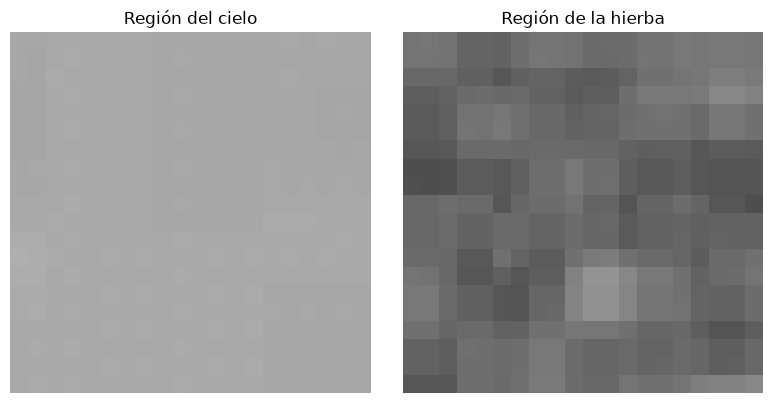

In [3]:
# ==========================================================
# Extracción de las regiones de interés
# ==========================================================

# Extraemos la región correspondiente al cielo.
cielo = img[80:100, 400:420]

# Extraemos la región correspondiente a la hierba.
hierba = img[490:510, 490:510]


# ==========================================================
# Visualización de ambas regiones
# ==========================================================

fig, ax = plt.subplots(1, 2, figsize=(8,4))

# Región del cielo
ax[0].imshow(cv2.cvtColor(cielo, cv2.COLOR_BGR2RGB))
ax[0].set_title("Región del cielo")
ax[0].axis("off")

# Región de la hierba
ax[1].imshow(cv2.cvtColor(hierba, cv2.COLOR_BGR2RGB))
ax[1].set_title("Región de la hierba")
ax[1].axis("off")

plt.tight_layout()
plt.show()

## 1.1 Matriz de Coocurrencia (GLCM)

La **Matriz de Coocurrencia de Niveles de Gris (Gray-Level Co-occurrence Matrix, GLCM)** es uno de los descriptores de textura más utilizados en el procesamiento digital de imágenes.

Este método analiza la frecuencia con la que dos niveles de intensidad aparecen juntos dentro de una determinada distancia y dirección. A partir de esta matriz es posible calcular diferentes características estadísticas que permiten describir la textura de una imagen.

En esta práctica se calcularán las siguientes propiedades para las regiones del **cielo** y la **hierba**:

- Contraste
- Disimilitud
- Homogeneidad
- ASM (Angular Second Moment)
- Energía
- Correlación

Finalmente, los resultados se presentarán en forma de tabla para facilitar su comparación.

In [4]:
# ==========================================================
# Matriz de Coocurrencia (GLCM)
# ==========================================================

# Si la librería tabulate no está instalada puede instalarse con:
# pip install tabulate

# Importamos la librería para mostrar tablas organizadas.
from tabulate import tabulate

# Importamos las funciones necesarias para calcular la
# Matriz de Coocurrencia y sus propiedades.
from skimage.feature import graycomatrix, graycoprops


# ==========================================================
# Encabezados de la tabla
# ==========================================================

headers = ["", "Cielo", "Hierba"]


# ==========================================================
# Listas donde se almacenarán los resultados
# ==========================================================

CN = ["Contraste"]
DIS = ["Disimilitud"]
H = ["Homogeneidad"]
ASM = ["ASM"]
E = ["Energía"]
COR = ["Correlación"]


# ==========================================================
# Regiones de interés
# ==========================================================

# Guardamos las regiones previamente extraídas.
patches = [cielo, hierba]


# ==========================================================
# Cálculo de los descriptores
# ==========================================================

for region in patches:

    # Convertimos la imagen a escala de grises.
    image = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)

    # Calculamos la Matriz de Coocurrencia.
    glcm = graycomatrix(
        image,
        distances=[5],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    # Extraemos cada una de las propiedades de textura.

    CN.append(graycoprops(glcm, "contrast")[0, 0])

    DIS.append(graycoprops(glcm, "dissimilarity")[0, 0])

    H.append(graycoprops(glcm, "homogeneity")[0, 0])

    ASM.append(graycoprops(glcm, "ASM")[0, 0])

    E.append(graycoprops(glcm, "energy")[0, 0])

    COR.append(graycoprops(glcm, "correlation")[0, 0])


# ==========================================================
# Construcción de la tabla
# ==========================================================

datos = [
    tuple(CN),
    tuple(DIS),
    tuple(H),
    tuple(ASM),
    tuple(E),
    tuple(COR)
]


# ==========================================================
# Visualización de resultados
# ==========================================================

print(tabulate(datos, headers=headers))

                 Cielo        Hierba
------------  --------  ------------
Contraste     3.68      333.393
Disimilitud   1.4        13.8533
Homogeneidad  0.512471    0.0921279
ASM           0.142717    0.00510556
Energía       0.377779    0.0714532
Correlación   0.190521   -0.0705127


## 1.2 Scale-Invariant Feature Transform (SIFT)

El algoritmo **SIFT (Scale-Invariant Feature Transform)** permite detectar puntos de interés dentro de una imagen que permanecen estables frente a cambios de escala, rotación e iluminación.

Cada punto de interés posee un descriptor numérico que representa sus características locales, permitiendo reconocer objetos incluso cuando aparecen desde diferentes perspectivas.

En esta práctica se detectarán los puntos clave de la imagen y posteriormente se visualizarán sobre la fotografía original.

Dimensiones del descriptor: (1672, 128)


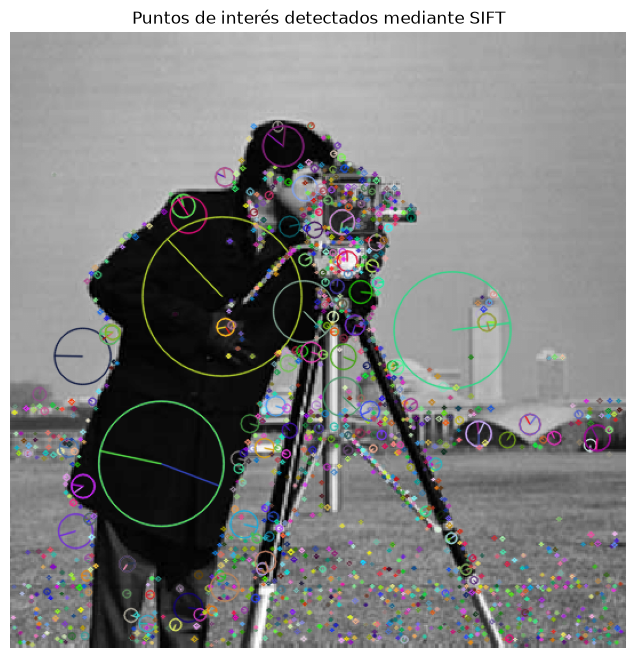

In [6]:
# ==========================================================
# Scale-Invariant Feature Transform (SIFT)
# ==========================================================

# Cargamos nuevamente la imagen original.
img = cv2.imread("images/photographer.png")


# ==========================================================
# Creación del detector SIFT
# ==========================================================

# Inicializamos el algoritmo SIFT.
sift = cv2.SIFT_create()


# ==========================================================
# Detección de puntos de interés
# ==========================================================

# Detectamos los puntos clave presentes en la imagen.
keypoints = sift.detect(img, None)


# ==========================================================
# Cálculo de los descriptores
# ==========================================================

# Para cada punto clave se calcula un descriptor de 128
# características que representa su información local.
keypoints, descriptors = sift.compute(img, keypoints)


# ==========================================================
# Información obtenida
# ==========================================================

print("Dimensiones del descriptor:", np.shape(descriptors))


# ==========================================================
# Visualización de los puntos clave
# ==========================================================

imagen_sift = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(imagen_sift, cv2.COLOR_BGR2RGB))
plt.title("Puntos de interés detectados mediante SIFT")
plt.axis("off")
plt.show()

## 1.3 Histogram of Oriented Gradients (HOG)

El **Histogram of Oriented Gradients (HOG)** es un descriptor de textura ampliamente utilizado para la detección y reconocimiento de objetos.

Su funcionamiento consiste en analizar la distribución de las direcciones de los gradientes presentes en una imagen. En lugar de utilizar directamente los valores de intensidad, HOG describe cómo cambian dichos valores, permitiendo representar la forma y estructura de los objetos.

En esta práctica se utilizará una imagen de un peatón, de la cual se seleccionará una región de interés que posteriormente será utilizada para calcular el descriptor HOG.

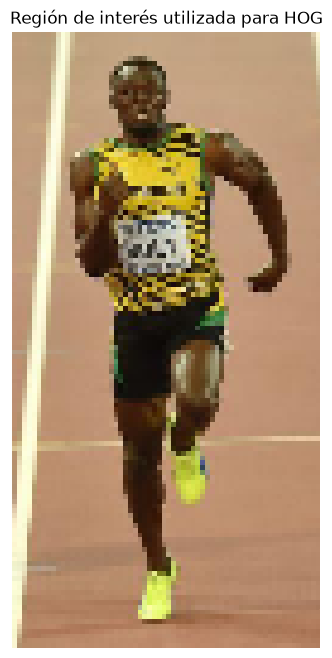

In [7]:
# ==========================================================
# Histogram of Oriented Gradients (HOG)
# ==========================================================

# Importamos la función io para leer imágenes mediante
# Scikit-Image.
from skimage import io


# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen del peatón.
img = io.imread("images/pedestrian.jpg")

# Convertimos la imagen a tipo float y normalizamos los
# valores de intensidad entre 0 y 1.
img = np.float32(img / 255)


# ==========================================================
# Selección de la región de interés
# ==========================================================

# Extraemos únicamente la región donde aparece el peatón.
crop = img[75:550, 475:700]

# Redimensionamos la imagen al tamaño utilizado por el
# descriptor HOG (64 x 128 píxeles).
crop = cv2.resize(crop, (64, 128))


# ==========================================================
# Visualización de la región seleccionada
# ==========================================================

plt.figure(figsize=(5,8))
plt.imshow(crop)
plt.title("Región de interés utilizada para HOG")
plt.axis("off")
plt.show()

### Cálculo del gradiente

El descriptor HOG se basa en el análisis del gradiente de intensidad de la imagen.

Para ello se utilizan los filtros de **Sobel**, los cuales permiten calcular las variaciones horizontales y verticales de la intensidad. Posteriormente se obtiene la magnitud y la orientación del gradiente en cada píxel.

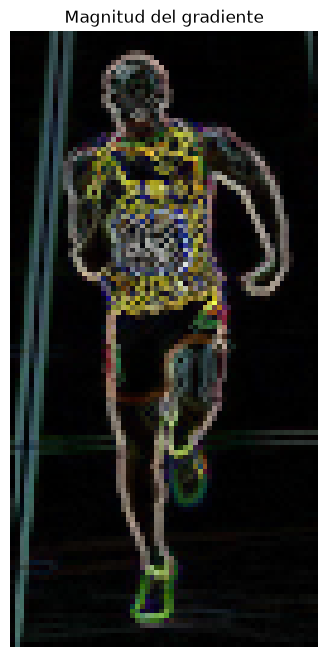

In [8]:
# ==========================================================
# Cálculo del gradiente mediante el operador de Sobel
# ==========================================================

# Convertimos la imagen a tipo float32 para realizar los
# cálculos del gradiente.
crop = np.float32(crop)


# ==========================================================
# Gradiente horizontal (X)
# ==========================================================

gx = cv2.Sobel(
    crop,
    cv2.CV_32F,
    1,
    0,
    ksize=1
)


# ==========================================================
# Gradiente vertical (Y)
# ==========================================================

gy = cv2.Sobel(
    crop,
    cv2.CV_32F,
    0,
    1,
    ksize=1
)


# ==========================================================
# Magnitud y dirección del gradiente
# ==========================================================

# Calculamos la magnitud y el ángulo del gradiente.
magnitud, angulo = cv2.cartToPolar(
    gx,
    gy,
    angleInDegrees=True
)


# ==========================================================
# Normalización de la magnitud
# ==========================================================

magnitud = magnitud / np.max(magnitud)


# ==========================================================
# Visualización de la magnitud del gradiente
# ==========================================================

plt.figure(figsize=(5,8))
plt.imshow(magnitud, cmap="gray")
plt.title("Magnitud del gradiente")
plt.axis("off")
plt.show()

### Cálculo del descriptor HOG

Una vez obtenido el gradiente de la imagen, se calcula el descriptor **Histogram of Oriented Gradients (HOG)**.

Este descriptor divide la imagen en pequeñas celdas, calcula un histograma con las orientaciones de los gradientes de cada una y posteriormente normaliza los resultados por bloques. El vector obtenido representa las características de textura y forma presentes en la imagen.

In [10]:
# ==========================================================
# Cálculo del descriptor HOG
# ==========================================================

from skimage.feature import hog

# Convertimos la imagen a escala de grises
crop_gray = cv2.cvtColor((crop * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)

# Calculamos el descriptor HOG
descriptor_hog = hog(
    crop_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    transform_sqrt=True,
    block_norm="L1"
)

# Mostramos información del descriptor
print("Número de características HOG:", descriptor_hog.shape)

print("\nPrimeros 20 valores del descriptor:")
print(descriptor_hog[:20])

Número de características HOG: (3780,)

Primeros 20 valores del descriptor:
[0.01020189 0.00185179 0.00087643 0.00158203 0.00764585 0.00111604
 0.00175556 0.00120876 0.01074466 0.42977158 0.00173992 0.00359592
 0.00315103 0.00203855 0.00279125 0.00086152 0.         0.01069854
 0.0860638  0.        ]


## 1.4 Local Binary Patterns (LBP)

El **Local Binary Pattern (LBP)** es uno de los descriptores de textura más utilizados en visión por computador debido a su simplicidad y eficiencia.

Su funcionamiento consiste en comparar el valor de intensidad de un píxel central con el de sus píxeles vecinos. El resultado de estas comparaciones genera un código binario que describe la textura local de la imagen.

Posteriormente, se calcula un histograma de estos códigos, el cual constituye el descriptor utilizado para caracterizar la textura de la imagen.

In [11]:
# ==========================================================
# Local Binary Patterns (LBP)
# ==========================================================

# Importamos la función necesaria para calcular el descriptor LBP.
from skimage.feature import local_binary_pattern


# ==========================================================
# Lectura de la imagen
# ==========================================================

# Cargamos la imagen que será utilizada para el análisis.
img = cv2.imread("images/photographer.png")


# ==========================================================
# Parámetros del algoritmo
# ==========================================================

# Radio utilizado para definir el vecindario.
R = 1

# Número de vecinos alrededor del píxel central.
P = 8 * R

# Pequeño valor utilizado para evitar divisiones entre cero
# durante la normalización del histograma.
epsilon = 1e-7


# ==========================================================
# Conversión a escala de grises
# ==========================================================

# El algoritmo LBP trabaja sobre imágenes en escala de grises.
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


# ==========================================================
# Cálculo del Local Binary Pattern
# ==========================================================

# Calculamos la imagen LBP utilizando el método uniforme.
lbp_image = local_binary_pattern(
    img_gray,
    P,
    R,
    method="uniform"
)


# ==========================================================
# Información de la imagen LBP
# ==========================================================

# Obtenemos los diferentes códigos LBP presentes y el número
# de veces que aparece cada uno.
valores, frecuencias = np.unique(
    lbp_image,
    return_counts=True
)


# ==========================================================
# Cálculo del histograma
# ==========================================================

# Convertimos la imagen a uint8 para trabajar con OpenCV.
lbp_uint8 = np.uint8(lbp_image)

# Calculamos el histograma.
hist = cv2.calcHist(
    [lbp_uint8.ravel()],
    [0],
    None,
    [P + 2],
    [0, P + 2]
)


# ==========================================================
# Normalización del histograma
# ==========================================================

# Convertimos el histograma a tipo float para normalizarlo.
hist = hist.astype("float")

# Normalizamos el histograma para que la suma de todos
# sus valores sea igual a 1.
hist /= (hist.sum() + epsilon)

### Visualización de los resultados

Una vez obtenido el descriptor LBP, se visualiza tanto la imagen original como la imagen transformada mediante **Local Binary Patterns**.

Finalmente, se representa el histograma normalizado, cuyos valores constituyen el descriptor de textura utilizado para caracterizar la imagen.

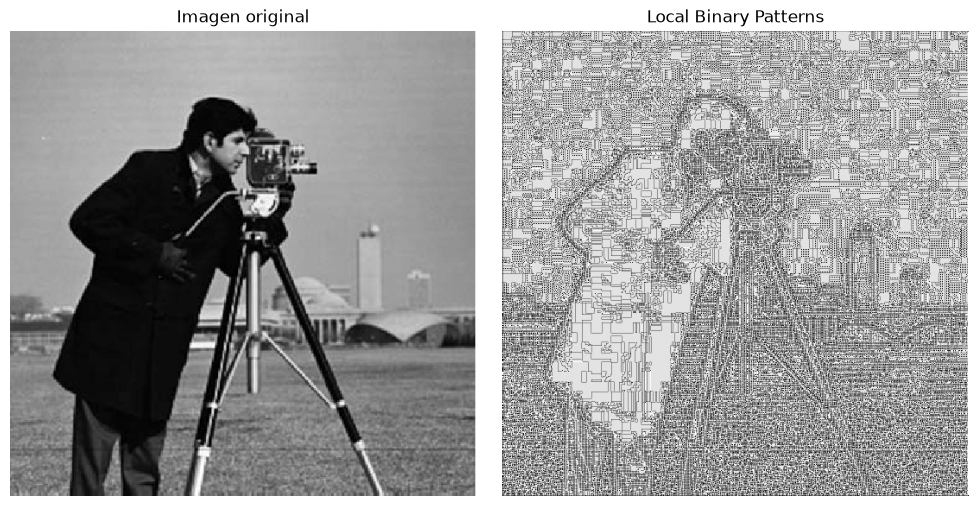

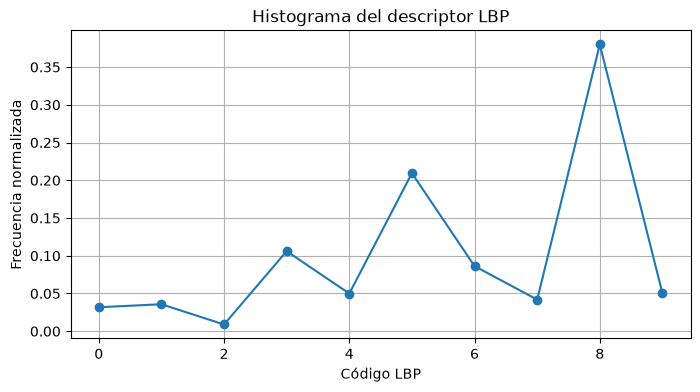

In [12]:
# ==========================================================
# Visualización de la imagen original y la imagen LBP
# ==========================================================

fig, ax = plt.subplots(1, 2, figsize=(10,5))

# Imagen original
ax[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Imagen original")
ax[0].axis("off")

# Imagen transformada mediante LBP
ax[1].imshow(lbp_uint8, cmap="gray")
ax[1].set_title("Local Binary Patterns")
ax[1].axis("off")

plt.tight_layout()
plt.show()


# ==========================================================
# Visualización del histograma
# ==========================================================

plt.figure(figsize=(8,4))

plt.plot(hist, marker="o")

plt.title("Histograma del descriptor LBP")

plt.xlabel("Código LBP")

plt.ylabel("Frecuencia normalizada")

plt.grid(True)

plt.show()

## Conclusión

En esta práctica se estudiaron distintos **descriptores de textura** utilizados en el procesamiento digital de imágenes. Mediante técnicas como **GLCM**, **SIFT**, **HOG** y **Local Binary Patterns (LBP)** fue posible extraer información representativa sobre la textura y las características locales de las imágenes.

Estos descriptores constituyen herramientas fundamentales en aplicaciones de visión por computador, ya que permiten realizar tareas como el reconocimiento de objetos, la clasificación de imágenes y el análisis automático de patrones.